# <span style= "color:purple"> Exploring Variability with Detrending and Removing Seasonal Cycles

## <span style= "color:purple"> Toy Examples

### <span style= "color:purple"> Detrending: 

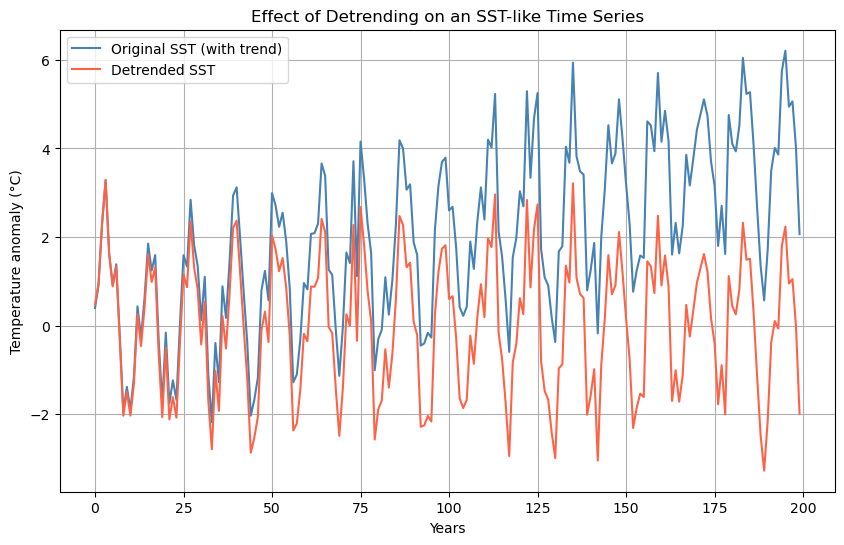

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

# Generate synthetic SST-like time series
np.random.seed(42)
years = np.arange(0, 200)
trend = 0.02 * years  # long-term warming trend
seasonal = 2 * np.sin(2 * np.pi * years / 12)  # seasonal cycle
noise = np.random.normal(0, 0.8, len(years))  # internal variability / noise

sst = trend + seasonal + noise

# Apply detrending
sst_detrended = detrend(sst)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(years, sst, label="Original SST (with trend)", color='steelblue')
plt.plot(years, sst_detrended, label="Detrended SST", color='tomato')
plt.xlabel("Years")
plt.ylabel("Temperature anomaly (°C)")
plt.title("Effect of Detrending on an SST-like Time Series")
plt.legend()
plt.grid(True)
plt.show()

### <span style= "color:purple"> Removing Seasonal Cycle:

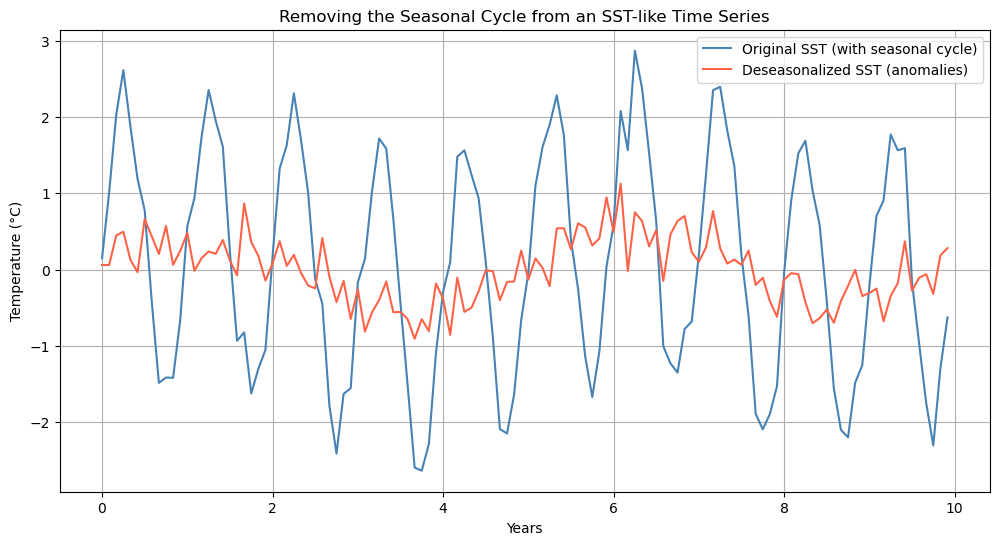

In [6]:
# Generate synthetic SST-like time series with a seasonal cycle and interannual variability
np.random.seed(42)
years = np.arange(0, 10*12)  # 10 years of monthly data
t = years / 12

# Components
trend = 0.02 * t  # small long-term trend
seasonal = 2 * np.sin(2 * np.pi * t)  # 1-year seasonal cycle
interannual = 0.5 * np.sin(2 * np.pi * t / 5)  # slow ENSO-like 5-year cycle
noise = np.random.normal(0, 0.3, len(t))

sst = trend + seasonal + interannual + noise

# Compute climatological seasonal cycle (mean for each month across years)
months = np.arange(12)
seasonal_climatology = np.array([sst[m::12].mean() for m in months])

# Remove seasonal cycle to get anomalies
sst_deseasonalized = np.array([sst[i] - seasonal_climatology[i % 12] for i in range(len(sst))])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(t, sst, label="Original SST (with seasonal cycle)", color="steelblue")
plt.plot(t, sst_deseasonalized, label="Deseasonalized SST (anomalies)", color="tomato")
plt.xlabel("Years")
plt.ylabel("Temperature (°C)")
plt.title("Removing the Seasonal Cycle from an SST-like Time Series")
plt.legend()
plt.grid(True)
plt.show()